In [ ]:
# 기본 경로 설정
# ===============================================================
import os
import requests

PROJECT_NUM = "13"

ROOT_DIR = os.getcwd()


try:
    from google.colab import drive, userdata
    IS_COLAB_MODE = True
    print("코랩 모드")

except ModuleNotFoundError as e:
    IS_COLAB_MODE = False
    ROOT_DIR = os.path.abspath(os.path.join(ROOT_DIR, ".."))
    print(f"{e}: 로컬 모드")


DATA_DIR = os.path.join(ROOT_DIR, "data")
RAW_DIR = os.path.join(DATA_DIR, "raw")
os.makedirs(DATA_DIR, exist_ok=True)


# 환경변수 로드 설정
def get_secret(key_name: str):
    if IS_COLAB_MODE:
        return userdata.get(key_name)
    else:
        from dotenv import load_dotenv
        load_dotenv(dotenv_path=os.path.join(ROOT_DIR, ".env"))
        return os.getenv(key_name)


if IS_COLAB_MODE:
    import subprocess

    drive.mount('/content/drive')

    # 압축 파일 확보
    if "raw.tar.gz" not in os.listdir():

        headers = {
            "Authorization": f"token {get_secret('GITHUB_PAT')}",
            "Accept": "application/vnd.github.v3+json"
        }

        release_url = f"https://api.github.com/repos/wonbywondev/ML-DL-data/releases/tags/data-v{PROJECT_NUM}"

        response = requests.get(release_url, headers=headers)
        asset_id = response.json().get('assets', [])[0]["id"]

        download_url = f"https://api.github.com/repos/wonbywondev/ML-DL-data/releases/assets/{asset_id}"
        download_headers = headers.copy()
        download_headers["Accept"] = "application/octet-stream"

        with requests.get(download_url, headers=download_headers, stream=True) as r:
            r.raise_for_status()
            with open("raw.tar.gz", 'wb') as f:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)

    print("· 압축 파일 있음")


    # 압축 해제 및 경로 처리
    if not os.path.exists(RAW_DIR):
        subprocess.run(["tar", "-xzvf", "raw.tar.gz", "-C", DATA_DIR], check=True)

    print("· 압축 해제 완료")
    print("· 환경 세팅 완료")


    DRIVE_DIR = os.path.join(ROOT_DIR, "drive", "MyDrive")
    SAVE_DIR = os.path.join(DRIVE_DIR, "runs", PROJECT_NUM)

    os.makedirs(SAVE_DIR, exist_ok=True)

코랩 모드
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
· 압축 파일 있음
· 압축 해제 완료
· 환경 세팅 완료


In [ ]:
# 기타 환경 설정
import torch
import matplotlib.pyplot as plt
import gc


# 시각화 관련 설정
if not IS_COLAB_MODE:
    import matplotlib.font_manager as fm
    try:
        plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
    except:
        try:
            plt.rcParams['font.family'] = 'NanumGothic'
        except:
            plt.rcParams['font.family'] = 'AppleGothic'

    plt.rcParams['axes.unicode_minus'] = False
    fm._load_fontmanager(try_read_cache=False)


# 디바이스 설정
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device("mps") # 맥 GPU
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda") # 윈도우 GPU
else:
    DEVICE = torch.device("cpu") # CPU


# 캐시 지우기 함수 생성
def clean_cache():
    gc.collect()
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        torch.mps.empty_cache()
    elif torch.cuda.is_available():
        torch.cuda.empty_cache()


# MallocStackLogging 에러 출력 방지
os.environ.pop("MallocStackLogging", None)
os.environ.pop("MallocStackLoggingNoCompact", None)
os.environ.pop("DYLD_INSERT_LIBRARIES", None)

In [ ]:
import random
import json
from pathlib import Path

raw_json_path_list = [
    str(path) for path in Path(RAW_DIR).rglob("*.json")
    if not path.name.startswith(".")
]

rand_idx = random.randint(1, len(raw_json_path_list))
rand_path = raw_json_path_list[rand_idx - 1]

with open(rand_path, "r", encoding="utf-8") as f:
    sample = json.load(f)

rand_idx = random.randint(1, len(sample))
sample[rand_idx - 1]

{'Index': '117582',
 'RawText': '원래 쓰던 믹서기가 고장나서 괜찮은 제품 찾다가 구매하게 되었어요~! 다기능 블렌더라고 하니까 요리의 폭도 넓어질 것 같은 기분에 이 제품으로 선택하게 되었답니닷ㅎㅎ다기능 블렌더인만큼 제품 구성이 어마어마하더라구요~~^^ 글라스 컨테이너는 기본이고 다지기 전용 컵, 글라스잔 두 세트, 스텐 텀블러, 다용도 분쇄컵까지... 알찬 구성에 완전 놀랐습니다^0^다만, 아무래도 소재가 유리이다보니까 냄새가 배지 않는 점은 좋긴 하지만 깨질 위험이 많아서 불안한 건 어쩔 수 없나봐용~~^^;; 그리고 용량이 좀 과하게 커서 부담스러웠어요ㅋㅋㅋ 좀 더 작은 용량이었어도 괜찮았을 것 같은 느낌이 들었달까??',
 'Source': 'SNS',
 'Domain': '가전',
 'MainCategory': '주방가전',
 'ProductName': '쿠닝 레트로 블렌더 소형 이유식 스무디 야채 5in1 다기능 블렌더MA-BL89',
 'ReviewScore': '3',
 'Syllable': '335',
 'Word': '75',
 'RDate': '20221121',
 'GeneralPolarity': '0',
 'Aspects': [{'Aspect': '제품구성',
   'SentimentText': ' 제품 구성이 어마어마하더라구요~~^^ 글라스 컨테이너는 기본이고 다지기 전용 컵, 글라스잔 두 세트, 스텐 텀블러, 다용도 분쇄컵까지... 알찬 구성에 완전 놀랐습니다^0^',
   'SentimentWord': '20',
   'SentimentPolarity': '1'},
  {'Aspect': '소재',
   'SentimentText': '소재가 유리이다보니까 냄새가 배지 않는 점은 좋긴 하지만',
   'SentimentWord': '8',
   'SentimentPolarity': '1'},
  {'Aspect': '내구성',
   'SentimentText': '깨질 위험이 많아서 불안한 건 어쩔 수 없

In [ ]:
import pandas as pd

column_list = ["RawText", "Word", "GeneralPolarity"]
all_data = []

for path in raw_json_path_list:
    with open(path, "r", encoding="utf-8") as f:
        dict_list = json.load(f)

        for item in dict_list:
            filtered_item = {key: item.get(key) for key in column_list}

            all_data.append(filtered_item)

filtered_df = pd.DataFrame(all_data, columns=column_list)

print(f"· 총 데이터: {len(filtered_df)}개")

· 총 데이터: 201616개


In [ ]:
print("[결측치]")

for column in column_list:
    if sum(filtered_df[column].isna()) > 0:
        print(f"· 결측 항목: {column}")
        print(f"· {sum(filtered_df[column].isna())}개")
        print(f"· 예시: \n{filtered_df[filtered_df[column].isna()].head(5)}")

        filtered_df = filtered_df.dropna()
        print(f"\n· 제거 후 데이터: {len(filtered_df)}개")

filtered_df["GeneralPolarity"] = filtered_df["GeneralPolarity"].astype(int)

[결측치]
· 결측 항목: GeneralPolarity
· 17091개
· 예시: 
                                               RawText Word GeneralPolarity
38   김장준비하면서 이번에는  OOO 라팔 만능 다용도 채칼 슬라이서를 구입했어요 ^^~...   71            None
97   코로나가 물러 갈 생각을 안하네요 우리 이웃님들도 조심하세요  요즘은 거의 새부리형...   71            None
113  봄날의 기운 듬뿍 받으셔서 힘찬 발걸음으로 거침없이 달리는 4월 한달 되시길 바랍니...   71            None
120  파릇파릇 새싹과 몽울몽울 꽃망울들로 설레임이 가득한 요즘에 인사드립니다  ㅇㅇ 치약...   67            None
138  소나기처럼 첫사랑을 앓기도 하였고 비를 피해 누군가와 우산을 나눠 쓴 기억도 납니다...   74            None

· 제거 후 데이터: 184525개


In [ ]:
print("[중복치]")

if sum(filtered_df["RawText"].duplicated()) > 0:
    print(filtered_df[filtered_df["RawText"].duplicated()].head(5))

else:
    print("· 중복치 없음")

[중복치]
· 중복치 없음


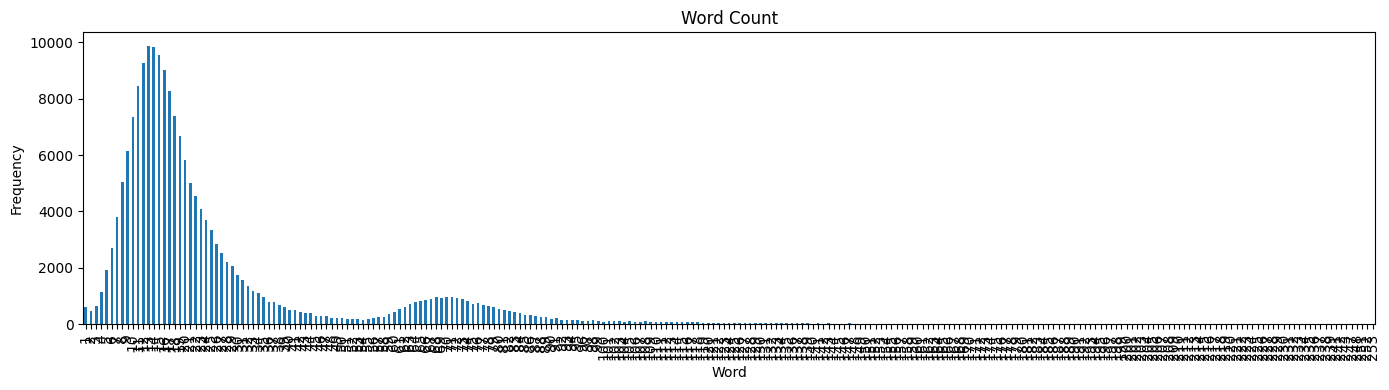

In [ ]:
filtered_df["Word"] = filtered_df["Word"].astype(int)

data = filtered_df["Word"].value_counts().sort_index()

plt.figure(figsize=(14,4))
data.plot(kind="bar")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.title("Word Count")
plt.tight_layout()
plt.show()

In [ ]:
print("[극단치]")

filtered_df = filtered_df[filtered_df["Word"] <= 50]

print(f"· 제거 후 데이터: {len(filtered_df)}개")

[극단치]
· 제거 후 데이터: 158825개


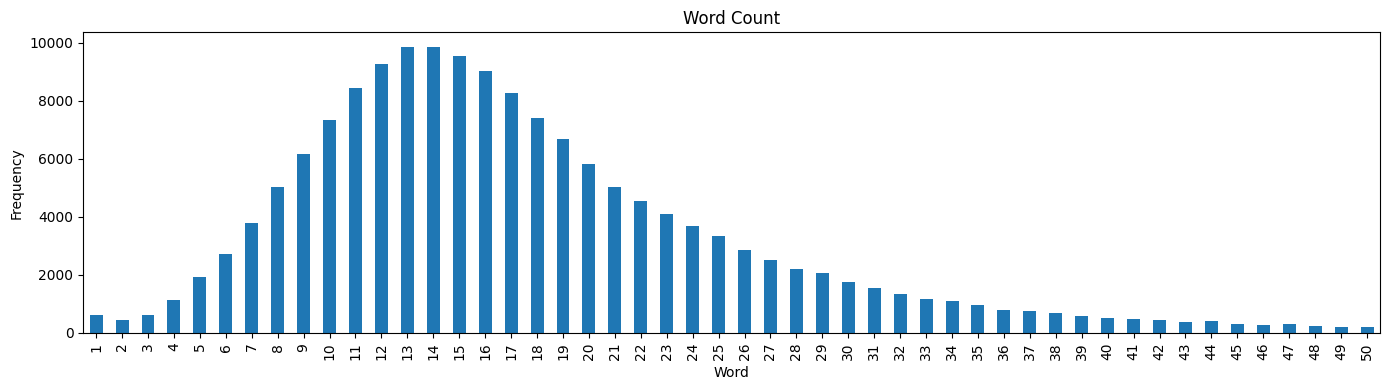

In [ ]:
data = filtered_df["Word"].value_counts().sort_index()

plt.figure(figsize=(14,4))
data.plot(kind="bar")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.title("Word Count")
plt.tight_layout()
plt.show()

filtered_df = filtered_df.drop("Word", axis=1)

In [ ]:
filtered_df = filtered_df.reset_index().drop("index", axis=1)

filtered_df["GeneralPolarity"] += 1

filtered_df["GeneralPolarity"].value_counts()

,count
GeneralPolarity,
2,100348
1,33299
0,25178


---

In [ ]:
RAW_TEXT_LIST = list(filtered_df["RawText"])
CLASS_LIST = list(filtered_df["GeneralPolarity"])

https://huggingface.co/tabularisai/multilingual-sentiment-analysis

In [ ]:
from torch.utils.data import Dataset

class BasicDataset(Dataset):
    def __init__(self):
        self.X_list = RAW_TEXT_LIST
        self.y_list = CLASS_LIST

    def __len__(self):
        return len(self.X_list)

    def __getitem__(self, index):
        text = self.X_list[index]

        X = tokenizer(
            text,
            add_special_tokens=True,
            max_length=512,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        y = self.y_list[index]

        return {
            "input_ids": X["input_ids"].squeeze(0),
            "attention_mask": X["attention_mask"].squeeze(0),
            "labels": torch.tensor(y, dtype=torch.long)
        }


BASIC_DATASET = BasicDataset()

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader, WeightedRandomSampler

train_indices, tmp_indices = train_test_split(
    list(range(len(BASIC_DATASET))),
    test_size=0.2,
    stratify=CLASS_LIST
)

val_indices, test_indices = train_test_split(
    list(range(len(tmp_indices))),
    test_size=0.5,
    stratify=[CLASS_LIST[idx] for idx in tmp_indices]
)

basic_train_subset = Subset(BASIC_DATASET, train_indices)
basic_val_subset = Subset(BASIC_DATASET, val_indices)
basic_test_subset = Subset(BASIC_DATASET, test_indices)

print(f"[분할 결과]")
print(f"· 기존 학습 데이터: {len(BASIC_DATASET)}개")
print(f"· 분할 후 학습 데이터: {len(train_indices)}개 ({len(train_indices) / len(BASIC_DATASET) * 100:.2f}%)")
print(f"· 분할 후 검증 데이터: {len(val_indices)}개 ({len(val_indices) / len(BASIC_DATASET) * 100:.2f}%)")
print(f"· 분할 후 테스트 데이터: {len(test_indices)}개 ({len(test_indices) / len(BASIC_DATASET) * 100:.2f}%)")

[분할 결과]
· 기존 학습 데이터: 158825개
· 분할 후 학습 데이터: 127060개 (80.00%)
· 분할 후 검증 데이터: 15882개 (10.00%)
· 분할 후 테스트 데이터: 15883개 (10.00%)


In [ ]:
# 샘플러 설정
labels = torch.tensor([CLASS_LIST[idx] for idx in train_indices])

class_counts = torch.bincount(labels)
class_weights = len(train_indices) / class_counts.float()
samples_weights = class_weights[labels]

basic_sampler = WeightedRandomSampler(
    weights=samples_weights,
    num_samples=len(samples_weights),
    replacement=True
    )

print(f"[학습 데이터]")
print(f"· 부정 리뷰: {class_counts[0]}개 ({class_counts[0] / len(labels) * 100:.2f}%)")
print(f"· 중립 리뷰: {class_counts[1]}개 ({class_counts[1] / len(labels) * 100:.2f}%)")
print(f"· 긍정 리뷰: {class_counts[2]}개 ({class_counts[2] / len(labels) * 100:.2f}%)")

print(f"\n[샘플러 가중치]")
print(f"· 부정 클래스: {class_weights[0]:.4f}")
print(f"· 중립 클래스: {class_weights[1]:.4f}")
print(f"· 긍정 클래스: {class_weights[2]:.4f}")


# 채널별 데이터 로더 설정
TRAIN_LOADER = DataLoader(basic_train_subset, batch_size=32, sampler=basic_sampler, shuffle=False, num_workers=2)
VAL_LOADER = DataLoader(basic_val_subset, batch_size=32, shuffle=False, num_workers=2)
TEST_LOADER = DataLoader(basic_test_subset, batch_size=32, shuffle=False, num_workers=2)

[학습 데이터]
· 부정 리뷰: 20143개 (15.85%)
· 중립 리뷰: 26639개 (20.97%)
· 긍정 리뷰: 80278개 (63.18%)

[샘플러 가중치]
· 부정 클래스: 6.3079
· 중립 클래스: 4.7697
· 긍정 클래스: 1.5827


In [ ]:
import torch.optim as optim
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "tabularisai/multilingual-sentiment-analysis"

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    ignore_mismatched_sizes=True
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

optimizer = optim.AdamW(model.parameters(), lr=2e-5)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at tabularisai/multilingual-sentiment-analysis and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([5]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([5, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a 

In [ ]:
# 학습 유틸리티 설정

# wandb
if IS_COLAB_MODE:
    subprocess.run(["pip", "install", "wandb", "-qU"])

import wandb

wandb.login(key=get_secret("WANDB_API_KEY"))


# 텔레그램
def send_telegram_msg(message):
    token = get_secret("TELEGRAM_BOT_TOKEN")
    chat_id = get_secret("TELEGRAM_CHAT_ID")

    url = f'https://api.telegram.org/bot{token}/sendMessage'
    payload = {
        'chat_id': chat_id,
        'text': message
    }

    requests.post(url, json=payload)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: wsi0720 (wsi0720-sungkyunkwan-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
class TrainerConfig:
    def __init__(self, mode, patience=3):
        self.mode = mode
        self.save_dir = os.path.join(SAVE_DIR, self.mode)
        os.makedirs(self.save_dir, exist_ok=True)

        self.patience = patience
        self.best_loss = float("inf")
        self.counter = 0
        self.early_stop = False

        self.time_dict = dict()


    def step(self, epoch, train_loss, val_loss, model, epoch_time):

        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0

            model.save_pretrained(os.path.join(self.save_dir, "best_model"))

            torch.save({
                "epoch": epoch,
                "optimizer_state_dict": optimizer.state_dict(),
                "train_loss": train_loss,
                "val_loss": val_loss
            }, os.path.join(self.save_dir, "best_model", "training_state.pt"))

        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


        model.save_pretrained(os.path.join(self.save_dir, "last_model"))

        torch.save({
            "epoch": epoch,
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": train_loss,
            "val_loss": val_loss
        }, os.path.join(self.save_dir, "last_model", "training_state.pt"))


        wandb.log({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "best_val_loss": self.best_loss
        })

        self.time_dict[epoch] = epoch_time

In [ ]:
import time
from tqdm.auto import tqdm

def train_model(start_epoch: int, num_epochs: int, model, optimizer, config: TrainerConfig):
    start_time = time.perf_counter()

    for epoch in range(start_epoch, start_epoch + num_epochs):
        epoch += 1
        clean_cache()

        # 학습 모드
        model.train()
        total_train_loss = 0

        train_pbar = tqdm(TRAIN_LOADER, desc=f"Epoch {epoch} [Train]")

        for batch in train_pbar:
            optimizer.zero_grad()

            batch = {key: value.to(DEVICE) for key, value in batch.items()}

            outputs = model(**batch)
            loss = outputs.loss

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

            train_pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        average_train_loss = total_train_loss / len(TRAIN_LOADER)
        print(f"· Epoch {epoch} Train Loss: {average_train_loss:.4f}")


        # 평가 모드
        model.eval()
        total_val_loss = 0

        val_pbar = tqdm(VAL_LOADER, desc=f"Epoch {epoch} [Val]")

        with torch.no_grad():
            for batch in val_pbar:
                batch = {key: value.to(DEVICE) for key, value in batch.items()}
                outputs = model(**batch)
                total_val_loss += outputs.loss.item()

                val_pbar.set_postfix({"val_loss": f"{outputs.loss.item():.4f}"})

        average_val_loss = total_val_loss / len(VAL_LOADER)

        end_time = time.perf_counter()
        epoch_time = (end_time - start_time) / 60

        print(f"· Epoch {epoch} Val Loss: {average_val_loss:.4f} (소요 시간: {epoch_time:.1f}분)")

        config.step(epoch, average_train_loss, average_val_loss, model, epoch_time)


        if config.early_stop:
            send_telegram_msg(f"{config.mode} epoch {epoch} 학습 완료(얼리 스톱)")
            print("Early Stopped")
            break

        else:
            send_telegram_msg(
                f"""
                {config.mode} epoch {epoch} 학습 완료
                · Train Loss: {average_train_loss:.4f} | Val Loss: {average_val_loss:.4f}
                · 소요 시간: {epoch_time:.1f}분
                """
            )

    send_telegram_msg("학습 완료")

In [ ]:
def get_checkpoint(resume_dir):
    checkpoint_path = os.path.join(resume_dir, "training_state.pt")
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    if not os.path.exists(checkpoint_path):
        start_epoch = 0
    else:
        checkpoint = torch.load(checkpoint_path)
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        start_epoch = checkpoint["epoch"]

    return optimizer, tokenizer, start_epoch

---

## Full Fine-Tuning

In [ ]:
fft_config = TrainerConfig(mode="FFT", patience=5)

id_path = os.path.join(fft_config.save_dir, f"wandb_id_{fft_config.mode}.txt")

try:
    with open(id_path, "r") as f:
        id = f.read().strip()
    resume = "must"

except FileNotFoundError:
    id = wandb.util.generate_id()
    with open(id_path, "w") as f:
        f.write(id)
    resume = "allow"


wandb.init(
    project=PROJECT_NUM,
    name="SEONGIL WON",
    entity="wsi0720-sungkyunkwan-university",
    resume=resume,
    dir=SAVE_DIR,
    id=id,
    config={"model": MODEL_NAME}
)

In [ ]:
num_epochs = 2

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    ignore_mismatched_sizes=True
)


resume_dir = os.path.join(fft_config.save_dir, "last_model")
if os.path.exists(resume_dir):
    model = AutoModelForSequenceClassification.from_pretrained(resume_dir)

model.to(DEVICE)

optimizer, tokenizer, start_epoch = get_checkpoint(resume_dir)


train_model(
    start_epoch,
    num_epochs,
    model,
    optimizer,
    fft_config
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at tabularisai/multilingual-sentiment-analysis and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([5]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([5, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 2 [Train]:   0%|          | 0/2648 [00:00<?, ?it/s]

KeyboardInterrupt: 

---

## QLoRA

In [47]:
qlora_config = TrainerConfig(mode="QLoRA", patience=5)

id_path = os.path.join(qlora_config.save_dir, f"wandb_id_{qlora_config.mode}.txt")


try:
    with open(id_path, "r") as f:
        id = f.read().strip()
    resume = "must"

except FileNotFoundError:
    id = wandb.util.generate_id()
    with open(id_path, "w") as f:
        f.write(id)
    resume = "allow"


wandb.init(
    project=PROJECT_NUM,
    name="SEONGIL WON",
    entity="wsi0720-sungkyunkwan-university",
    resume=resume,
    dir=SAVE_DIR,
    id=id,
    config={"model": MODEL_NAME}
)

best_val_loss,0.70895
epoch,1
train_loss,0.85801
val_loss,0.70895


In [48]:
from peft import LoraConfig, TaskType, get_peft_model, prepare_model_for_kbit_training, PeftModel

try:
    from transformers import BitsAndBytesConfig
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,                 # 4bit로 모델 로딩
        bnb_4bit_quant_type="nf4",         # 학습 안정성이 좋은 NF4 방식
        bnb_4bit_use_double_quant=True,    # 한 번 더 압축 → 메모리 절약
        bnb_4bit_compute_dtype=torch.float16  # 계산은 FP16으로 수행
    )
except ImportError:
    subprocess.run(["pip", "install", "-U", "bitsandbytes"])

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,                 # 4bit로 모델 로딩
        bnb_4bit_quant_type="nf4",         # 학습 안정성이 좋은 NF4 방식
        bnb_4bit_use_double_quant=True,    # 한 번 더 압축 → 메모리 절약
        bnb_4bit_compute_dtype=torch.float16  # 계산은 FP16으로 수행
    )

lora_config = LoraConfig(
                    r=8,                 # 저랭크(Low-rank) 행렬의 차원
                    lora_alpha=16,       # LoRA 스케일링 계수
                    lora_dropout=0.05,   # 과적합 방지용 dropout
                    task_type=TaskType.SEQ_CLS,
                    target_modules=["q_lin", "v_lin"],
                    modules_to_save=["classifier", "pre_classifier"]
)

In [49]:
# 채널별 데이터 로더 설정
TRAIN_LOADER = DataLoader(basic_train_subset, batch_size=256, sampler=basic_sampler, shuffle=False, num_workers=2)
VAL_LOADER = DataLoader(basic_val_subset, batch_size=256, shuffle=False, num_workers=2)
TEST_LOADER = DataLoader(basic_test_subset, batch_size=256, shuffle=False, num_workers=2)

In [50]:
num_epochs = 2


model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    quantization_config=bnb_config,
    ignore_mismatched_sizes=True,
    device_map="auto"
)


model = prepare_model_for_kbit_training(model)

for name, module in model.named_modules():
    if "classifier" in name or "pre_classifier" in name:
        for param in module.parameters():
            param.data = param.data.to(torch.float32)


# last.pt 로드
resume_dir = os.path.join(qlora_config.save_dir, "last_model")

if not os.path.exists(resume_dir):
    model = get_peft_model(model, lora_config)

else:
    model = PeftModel.from_pretrained(
        model,
        resume_dir,
        is_trainable=True
    )

model.to(DEVICE)

optimizer, tokenizer, start_epoch = get_checkpoint(resume_dir)


train_model(
    start_epoch,
    num_epochs,
    model,
    optimizer,
    qlora_config
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at tabularisai/multilingual-sentiment-analysis and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([5]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([5, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 2 [Train]:   0%|          | 0/497 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


· Epoch 2 Train Loss: 0.6249


Epoch 2 [Val]:   0%|          | 0/63 [00:00<?, ?it/s]

· Epoch 2 Val Loss: 0.6398 (소요 시간: 56.5분)


Epoch 3 [Train]:   0%|          | 0/497 [00:00<?, ?it/s]

· Epoch 3 Train Loss: 0.5598


Epoch 3 [Val]:   0%|          | 0/63 [00:00<?, ?it/s]

· Epoch 3 Val Loss: 0.5718 (소요 시간: 113.0분)


---

## 시각화

In [ ]:
def prepare_best_model(config: TrainerConfig):

    best_dir = os.path.join(config.save_dir, "best_model")


    if config == fft_config:
        model = AutoModelForSequenceClassification.from_pretrained(best_dir)


    else:
        model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME,
            num_labels=3,
            quantization_config=bnb_config,
            ignore_mismatched_sizes=True,
            device_map="auto"
        )

        model = prepare_model_for_kbit_training(model)

        for name, module in model.named_modules():
            if "classifier" in name or "pre_classifier" in name:
                for param in module.parameters():
                    param.data = param.data.to(torch.float32)

        model = PeftModel.from_pretrained(
            model,
            best_dir,
            is_trainable=True
        )

    model.to(DEVICE)

    return model

In [ ]:
import numpy as np

def evaluate(model):
    model.eval()

    y_pred_list = list()
    y_list = list()

    test_pbar = tqdm(TEST_LOADER, desc="[Test]")

    with torch.no_grad():
        for batch in test_pbar:
            inputs = {key: value.to(DEVICE) for key, value in batch.items() if key != "labels"}
            ys = batch["labels"].to(DEVICE)

            outputs = model(**inputs)

            y_preds = torch.argmax(outputs.logits, dim=1)

            y_pred_list.extend(y_preds.cpu().numpy())
            y_list.extend(ys.cpu().numpy())

    y_list = np.array(y_list)
    y_pred_list = np.array(y_pred_list)

    return y_list, y_pred_list

In [ ]:
f_model = prepare_best_model(fft_config)
q_model = prepare_best_model(qlora_config)

f_label_list, f_pred_list = evaluate(f_model)
q_label_list, q_pred_list = evaluate(q_model)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at tabularisai/multilingual-sentiment-analysis and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([5]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([5, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[Test]:   0%|          | 0/63 [00:00<?, ?it/s]

[Test]:   0%|          | 0/63 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c5ed7d47420>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
Exception ignored in:     <function _MultiProcessingDataLoaderIter.__del__ at 0x7c5ed7d47420>assert self._parent_pid == os.getpid(), 'can only test a child process'

 Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
         self._shutdown_workers() 
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
       ^if w.is_alive():
^ ^  ^^   ^ ^^^^^^^^^^^^^^^^^^^

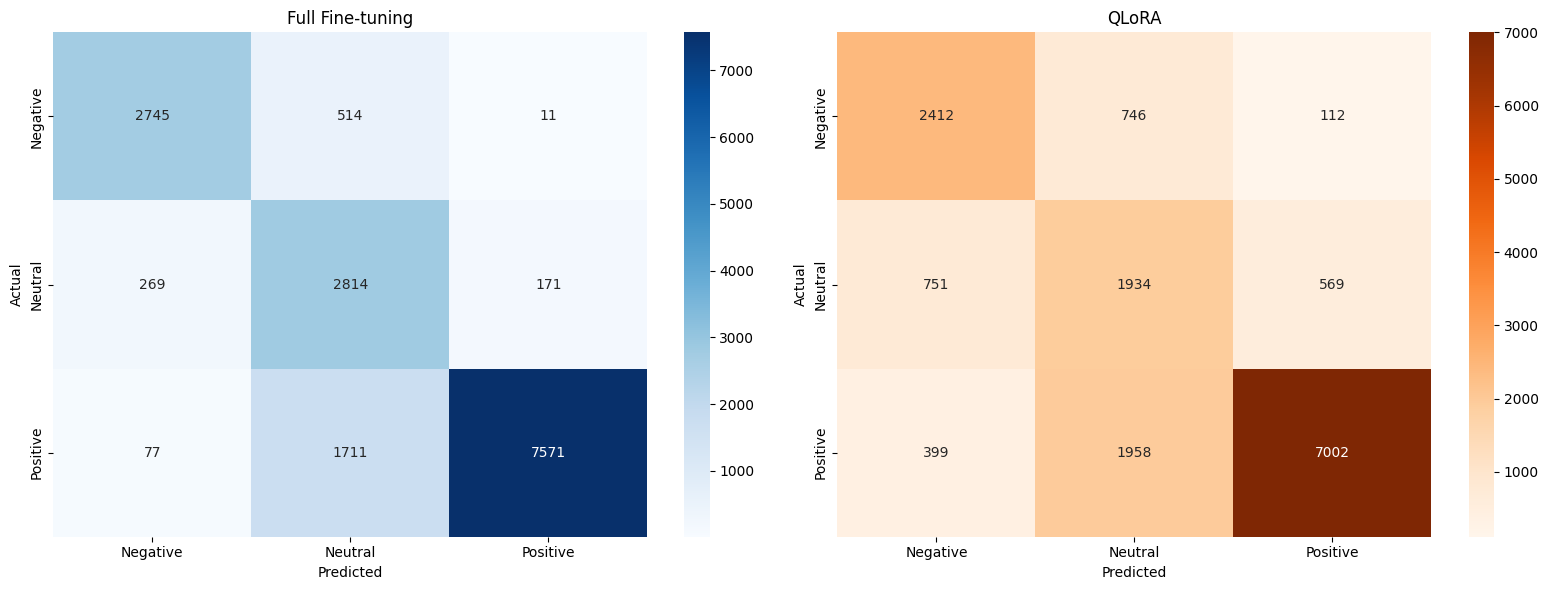


F1-score


,Full Fine,QLoRA,better,diff
Negative,0.8631,0.7061,Full Fine,0.1570
Neutral,0.6786,0.4901,Full Fine,0.1885
Positive,0.8849,0.8217,Full Fine,0.0631
accuracy,0.8267,0.7145,Full Fine,0.1122
macro avg,0.8089,0.6726,Full Fine,0.1362
weighted avg,0.8381,0.7300,Full Fine,0.1081



Full Fine


,precision,recall,f1-score,support
Negative,0.8881,0.8394,0.8631,3270.0000
Neutral,0.5584,0.8648,0.6786,3254.0000
Positive,0.9765,0.8090,0.8849,9359.0000
accuracy,0.8267,0.8267,0.8267,0.8267
macro avg,0.8077,0.8377,0.8089,15883.0000
weighted avg,0.8727,0.8267,0.8381,15883.0000



QLoRA


,precision,recall,f1-score,support
Negative,0.6771,0.7376,0.7061,3270.0000
Neutral,0.4170,0.5943,0.4901,3254.0000
Positive,0.9114,0.7482,0.8217,9359.0000
accuracy,0.7145,0.7145,0.7145,0.7145
macro avg,0.6685,0.6934,0.6726,15883.0000
weighted avg,0.7619,0.7145,0.7300,15883.0000


In [45]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

target_names = ["Negative", "Neutral", "Positive"]


f_cm = confusion_matrix(f_label_list, f_pred_list)
q_cm = confusion_matrix(q_label_list, q_pred_list)



fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full Fine-tuning 히트맵
sns.heatmap(f_cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=target_names, yticklabels=target_names)
axes[0].set_title("Full Fine-tuning")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# QLoRA 히트맵
sns.heatmap(q_cm, annot=True, fmt="d", cmap="Oranges", ax=axes[1],
            xticklabels=target_names, yticklabels=target_names)
axes[1].set_title("QLoRA")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()



f_result_df = pd.DataFrame(
    classification_report(
        f_label_list,
        f_pred_list,
        target_names=target_names,
        output_dict=True
    )
).transpose()

q_result_df = pd.DataFrame(
    classification_report(
        q_label_list,
        q_pred_list,
        target_names=target_names,
        output_dict=True
    )
).transpose()


compare_df = pd.DataFrame({
    "Full Fine": f_result_df["f1-score"],
    "QLoRA": q_result_df["f1-score"]
})

compare_df["better"] = np.where(
    compare_df["QLoRA"] > compare_df["Full Fine"],
    "QLoRA",
    "Full Fine"
)

compare_df["diff"] = abs(compare_df["QLoRA"] - compare_df["Full Fine"])



print("\nF1-score")
display(compare_df.round(4))


print("\nFull Fine")
display(f_result_df.round(4))

print("\nQLoRA")
display(q_result_df.round(4))